# 05 — Paper-style Visual Results for Flash Drought in Indonesia

Notebook ini adalah **Notebook ke-5** untuk menyusun hasil penelitian menjadi **peta, grafik, dan tabel visual** yang siap dipakai untuk menjelaskan hasil utama secara ilmiah, mirip gaya paper yang Anda upload.

## Fungsi notebook
Notebook ini **tidak** menghitung ulang ERA5-Land hourly dan **tidak** mendeteksi ulang flash drought.  
Notebook ini hanya membaca output yang sudah Anda hasilkan dari:

- `03d_FINAL_CLIMATOLOGY_FAST_v3`
- `04b_ROBUST_DRIVER_ANALYSIS_FAST`
- `03e_SENSITIVITY_ONSET_4_vs_5`
- `03f_SENSITIVITY_PERSISTENCE_2_3_4`
- `03g_SENSITIVITY_PERCENTILE_METHOD`

Lalu notebook ini akan membuat visual utama untuk paper/skripsi:

- **Figure 1**: occurrence probability dan frequency
- **Figure 2**: onset speed, duration, persistence, severity
- **Figure 3**: seasonality dan interannual variability
- **Figure 4**: event-aligned meteorological evolution
- **Figure 5**: physical-driver fingerprint
- **Figure 6**: methodological robustness / sensitivity summary
- **Figure S1**: hotspot masks

## Prinsip ilmiah
- Gunakan istilah **detection**, **sensitivity**, **consistency**, dan **robustness**.
- Jangan tulis **validation** jika belum memakai dataset independen.
- Notebook ini difokuskan untuk **komunikasi visual hasil**.


In [1]:
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("once")

BASE = Path(r"D:\ERA5_LAND")

CLIM_DIR = BASE / "output_fd_03d_paper_climatology"
DRIVER_DIR = BASE / "output_fd_04b_robust_drivers_fast"
ONSET_DIR = BASE / "output_fd_03e_onset_sensitivity"
PERSIST_DIR = BASE / "output_fd_03f_persistence_sensitivity"
PCT_DIR = BASE / "output_fd_03g_percentile_sensitivity"

OUT = BASE / "output_fd_05_paper_visual_results"
OUT.mkdir(parents=True, exist_ok=True)

FIG_DPI = 300
ANALYSIS_START = 1996
ANALYSIS_END = 2024
N_YEARS = ANALYSIS_END - ANALYSIS_START + 1

CLIM_NC = CLIM_DIR / "fd_benchmark_climatology_metrics_1996_2024.nc"
HOTSPOT_NC = CLIM_DIR / "fd_benchmark_hotspot_masks.nc"
SEASON_CSV = CLIM_DIR / "seasonal_monthly_onset_contribution.csv"
ANNUAL_CSV = CLIM_DIR / "annual_spatial_metrics_1996_2024.csv"
EVENT_SUMMARY_CSV = CLIM_DIR / "benchmark_event_characteristics_summary.csv"
TREND_CSV = CLIM_DIR / "annual_trend_screening.csv"

LAG_CSV = DRIVER_DIR / "year_block_onset_aligned_composite_bootstrap95.csv"
PRE_CSV = DRIVER_DIR / "preconditioning_summary.csv"
PHASE_CSV = DRIVER_DIR / "rapid_development_driver_states_bootstrap95.csv"
PHASE_YEAR_CSV = DRIVER_DIR / "rapid_development_driver_states_by_year.csv"
CORE_CSV = DRIVER_DIR / "drought_core_meteorology_bootstrap95.csv"

ONSET_SUMMARY_CSV = ONSET_DIR / "onset_4_vs_5_summary.csv"
ONSET_CONSIST_CSV = ONSET_DIR / "onset_4_vs_5_spatial_consistency.csv"

PERSIST_SUMMARY_CSV = PERSIST_DIR / "persistence_2_3_4_summary.csv"
PERSIST_CONSIST_CSV = PERSIST_DIR / "persistence_spatial_consistency.csv"

PCT_AGREE_CSV = PCT_DIR / "percentile_method_agreement.csv"
PCT_SUMMARY_CSV = PCT_DIR / "percentile_method_detection_summary.csv"
PCT_CONSIST_CSV = PCT_DIR / "percentile_method_detection_consistency.csv"

required = [
    CLIM_NC, HOTSPOT_NC, SEASON_CSV, ANNUAL_CSV, EVENT_SUMMARY_CSV,
    LAG_CSV, PRE_CSV, PHASE_CSV, PHASE_YEAR_CSV, CORE_CSV
]
for p in required:
    print("OK" if p.exists() else "MISSING", p.name)


OK fd_benchmark_climatology_metrics_1996_2024.nc
OK fd_benchmark_hotspot_masks.nc
OK seasonal_monthly_onset_contribution.csv
OK annual_spatial_metrics_1996_2024.csv
OK benchmark_event_characteristics_summary.csv
OK year_block_onset_aligned_composite_bootstrap95.csv
OK preconditioning_summary.csv
OK rapid_development_driver_states_bootstrap95.csv
OK rapid_development_driver_states_by_year.csv
OK drought_core_meteorology_bootstrap95.csv


## 1. Load products


In [2]:
clim = xr.open_dataset(CLIM_NC)
hot = xr.open_dataset(HOTSPOT_NC)
season = pd.read_csv(SEASON_CSV)
annual = pd.read_csv(ANNUAL_CSV)
event_summary = pd.read_csv(EVENT_SUMMARY_CSV)
trend = pd.read_csv(TREND_CSV) if TREND_CSV.exists() else None

lag = pd.read_csv(LAG_CSV)
pre = pd.read_csv(PRE_CSV)
phase = pd.read_csv(PHASE_CSV)
phase_year = pd.read_csv(PHASE_YEAR_CSV)
core = pd.read_csv(CORE_CSV)

onset_summary = pd.read_csv(ONSET_SUMMARY_CSV) if ONSET_SUMMARY_CSV.exists() else None
onset_consist = pd.read_csv(ONSET_CONSIST_CSV) if ONSET_CONSIST_CSV.exists() else None

persist_summary = pd.read_csv(PERSIST_SUMMARY_CSV) if PERSIST_SUMMARY_CSV.exists() else None
persist_consist = pd.read_csv(PERSIST_CONSIST_CSV) if PERSIST_CONSIST_CSV.exists() else None

pct_agree = pd.read_csv(PCT_AGREE_CSV) if PCT_AGREE_CSV.exists() else None
pct_summary = pd.read_csv(PCT_SUMMARY_CSV) if PCT_SUMMARY_CSV.exists() else None
pct_consist = pd.read_csv(PCT_CONSIST_CSV) if PCT_CONSIST_CSV.exists() else None

display(event_summary)


<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


,variable,unit,n_gridcell_events,mean,median,q25,q75
0,onset_speed_at_start,percentile points pentad-1,559676,32.961132,30.526993,19.280205,41.773781
1,onset_time_pentads_at_start,pentads,559676,1.720956,2.000000,1.000000,2.000000
2,duration_pentads_at_start,pentads,559676,7.648331,6.000000,5.000000,8.000000
3,below_p20_pentads_at_start,pentads,559676,5.927374,4.000000,3.000000,6.000000
4,severity_p40_at_start,percentile-point pentads,559676,195.640594,133.161957,101.388176,196.349609
5,minimum_percentile_at_start,percentile,559676,5.382042,5.012854,1.799486,8.226221


In [3]:
def draw_map(ax, da, title, cbar_label):
    im = ax.pcolormesh(da["longitude"], da["latitude"], da, shading="auto")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)
    return im

def theilsen_line(ax, x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() >= 3:
        slope, intercept, _, _ = stats.theilslopes(y[ok], x[ok])
        ax.plot(x, intercept + slope*x, linestyle="--", linewidth=1.2)

def metric_phase(name):
    row = phase.loc[phase["metric"] == name].iloc[0]
    return float(row["mean"]), float(row["ci95_low"]), float(row["ci95_high"])

def metric_lag(var, lag_value):
    row = lag[(lag["variable"] == var) & (lag["lag"] == lag_value)].iloc[0]
    return row


# Figure 1 — Benchmark flash drought occurrence and frequency


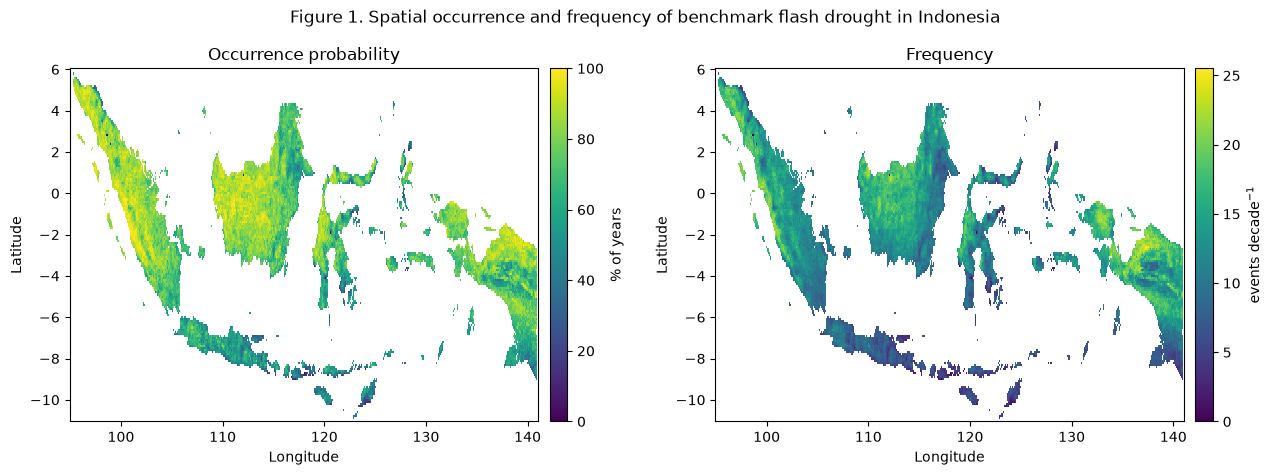

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
jobs = [
    ("occurrence_probability_percent", "Occurrence probability", "% of years"),
    ("events_per_decade", "Frequency", "events decade$^{-1}$"),
]
for ax, (var, title, cbar_label) in zip(axes, jobs):
    im = draw_map(ax, clim[var], title, cbar_label)
    cb = fig.colorbar(im, ax=ax, pad=0.02)
    cb.set_label(cbar_label)
fig.suptitle("Figure 1. Spatial occurrence and frequency of benchmark flash drought in Indonesia")
fig.tight_layout()
fig.savefig(OUT / "Figure1_occurrence_frequency.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


# Figure 2 — Onset and severity characteristics


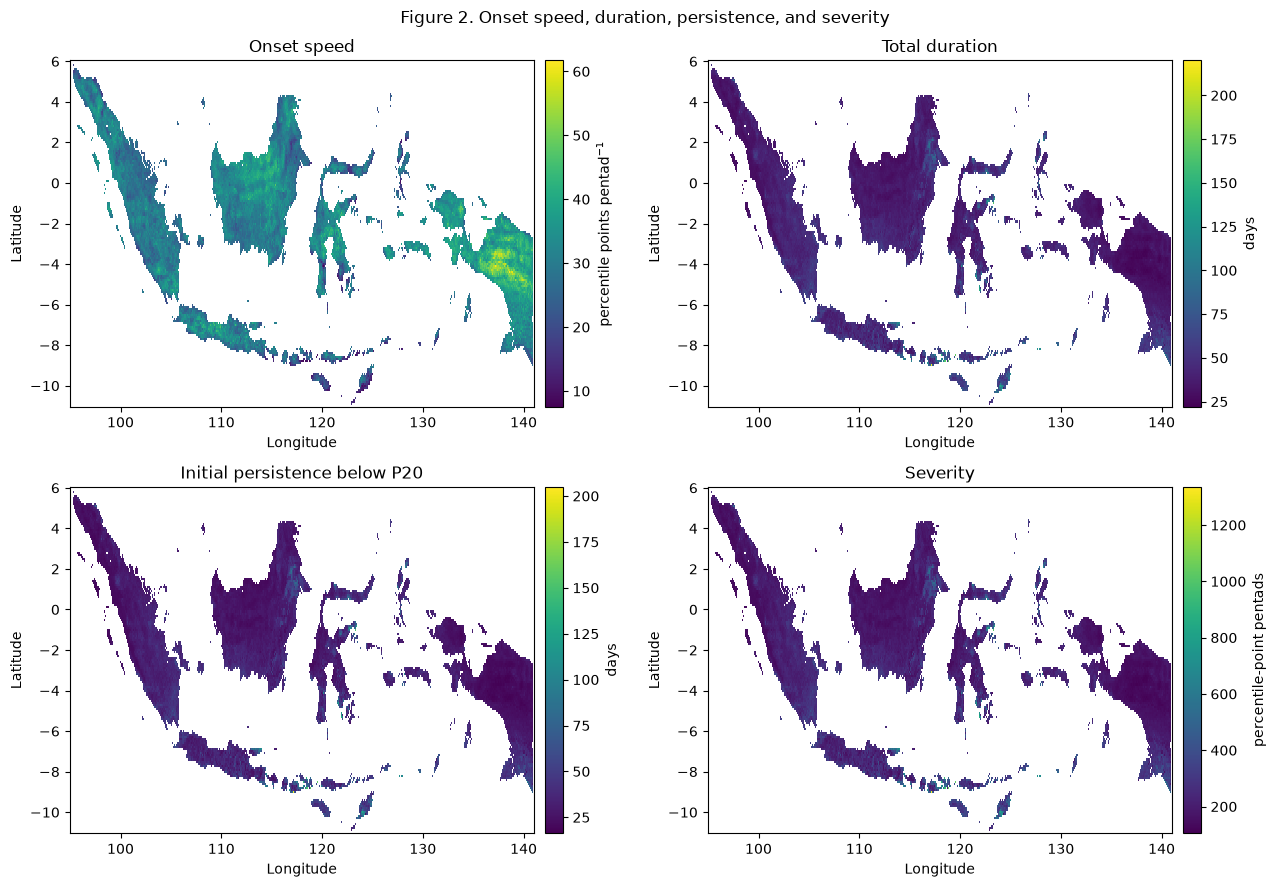

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
jobs = [
    ("mean_onset_speed_pp_per_pentad", "Onset speed", "percentile points pentad$^{-1}$"),
    ("mean_total_duration_days", "Total duration", "days"),
    ("mean_initial_p20_persistence_days", "Initial persistence below P20", "days"),
    ("mean_severity_p40_pp_pentad", "Severity", "percentile-point pentads"),
]
for ax, (var, title, cbar_label) in zip(axes.ravel(), jobs):
    im = draw_map(ax, clim[var], title, cbar_label)
    cb = fig.colorbar(im, ax=ax, pad=0.02)
    cb.set_label(cbar_label)
fig.suptitle("Figure 2. Onset speed, duration, persistence, and severity")
fig.tight_layout()
fig.savefig(OUT / "Figure2_onset_duration_persistence_severity.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


# Figure 3 — Seasonality and interannual variability


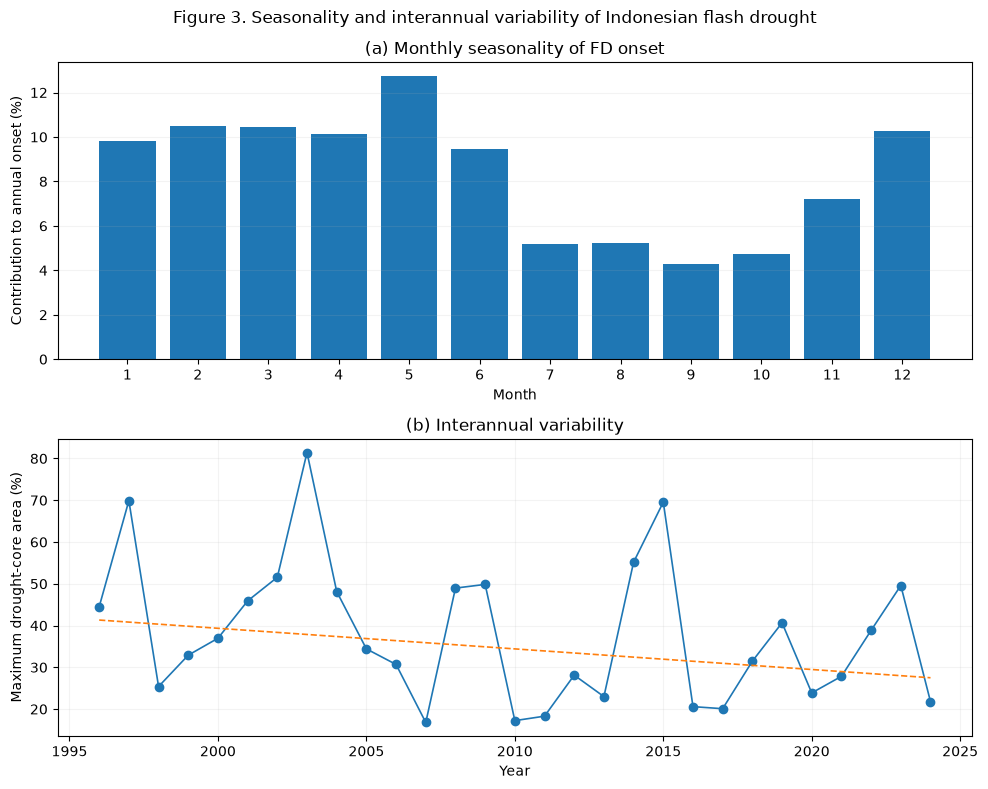

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes[0].bar(season["month"], season["contribution_percent"])
axes[0].set_xticks(range(1, 13))
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Contribution to annual onset (%)")
axes[0].set_title("(a) Monthly seasonality of FD onset")
axes[0].grid(axis="y", alpha=0.15)

axes[1].plot(annual["year"], annual["maximum_drought_core_area_percent"], marker="o", linewidth=1.2)
theilsen_line(axes[1], annual["year"], annual["maximum_drought_core_area_percent"])
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Maximum drought-core area (%)")
axes[1].set_title("(b) Interannual variability")
axes[1].grid(alpha=0.15)

fig.suptitle("Figure 3. Seasonality and interannual variability of Indonesian flash drought")
fig.tight_layout()
fig.savefig(OUT / "Figure3_seasonality_interannual.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


# Figure 4 — Event-aligned meteorological evolution


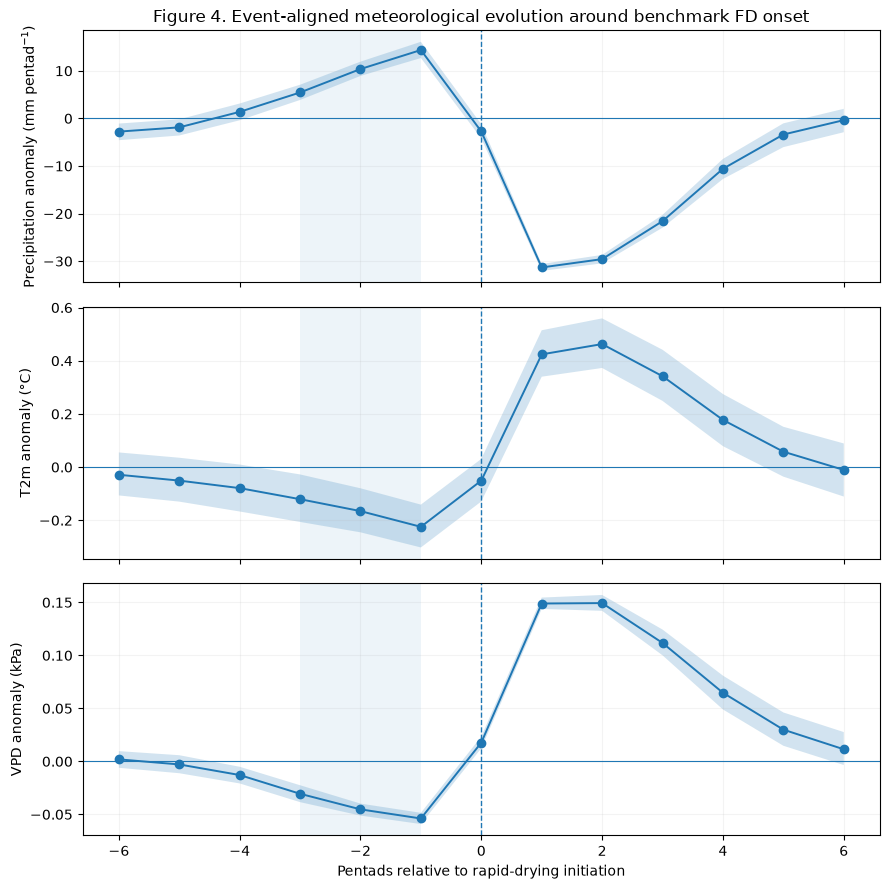

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
specs = [
    ("tp_anom_mm", "Precipitation anomaly (mm pentad$^{-1}$)"),
    ("t2m_anom_c", "T2m anomaly (°C)"),
    ("vpd_anom_kpa", "VPD anomaly (kPa)"),
]
for ax, (var, ylabel) in zip(axes, specs):
    sub = lag[lag["variable"] == var].sort_values("lag")
    ax.plot(sub["lag"], sub["mean"], marker="o", linewidth=1.4)
    ax.fill_between(sub["lag"], sub["ci95_low"], sub["ci95_high"], alpha=0.2)
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linestyle="--", linewidth=1.0)
    ax.axvspan(-3, -1, alpha=0.08)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.15)
axes[0].set_title("Figure 4. Event-aligned meteorological evolution around benchmark FD onset")
axes[-1].set_xlabel("Pentads relative to rapid-drying initiation")
fig.tight_layout()
fig.savefig(OUT / "Figure4_event_aligned_meteorology.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


# Figure 5 — Driver fingerprint during rapid development


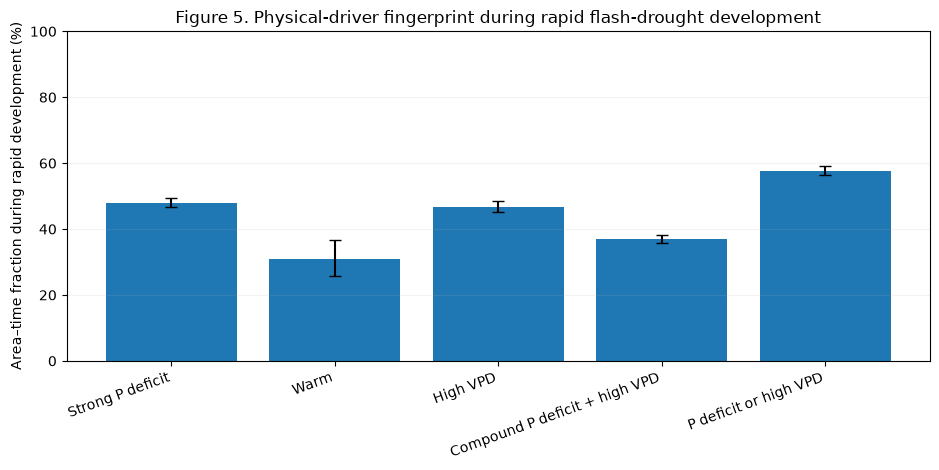

In [8]:
fraction_metrics = [
    ("strong_precip_deficit_fraction", "Strong P deficit"),
    ("warm_fraction", "Warm"),
    ("high_vpd_fraction", "High VPD"),
    ("compound_pdef_highvpd_fraction", "Compound P deficit + high VPD"),
    ("either_pdef_or_highvpd_fraction", "P deficit or high VPD"),
]
labels, means, err_lo, err_hi = [], [], [], []
for key, label in fraction_metrics:
    m, lo, hi = metric_phase(key)
    labels.append(label)
    means.append(m * 100.0)
    err_lo.append((m - lo) * 100.0)
    err_hi.append((hi - m) * 100.0)

fig, ax = plt.subplots(figsize=(9.5, 4.8))
x = np.arange(len(labels))
ax.bar(x, means, yerr=np.vstack([err_lo, err_hi]), capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Area–time fraction during rapid development (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.15)
ax.set_title("Figure 5. Physical-driver fingerprint during rapid flash-drought development")
fig.tight_layout()
fig.savefig(OUT / "Figure5_driver_fingerprint.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


In [9]:
pdef = metric_phase("strong_precip_deficit_fraction")[0]
hvpd = metric_phase("high_vpd_fraction")[0]
compound = metric_phase("compound_pdef_highvpd_fraction")[0]
either = metric_phase("either_pdef_or_highvpd_fraction")[0]

driver_partition = pd.DataFrame({
    "driver_state": [
        "P-deficit only",
        "High-VPD only",
        "Compound P-deficit + high-VPD",
        "Neither strong threshold",
    ],
    "fraction": [
        pdef - compound,
        hvpd - compound,
        compound,
        1.0 - either,
    ],
})
driver_partition["percent"] = driver_partition["fraction"] * 100.0
driver_partition.to_csv(OUT / "Table_driver_partition.csv", index=False)
display(driver_partition)


,driver_state,fraction,percent
0,P-deficit only,0.109006,10.900607
1,High-VPD only,0.097403,9.740319
2,Compound P-deficit + high-VPD,0.370117,37.011711
3,Neither strong threshold,0.423474,42.347363


# Figure 6 — Robustness / sensitivity summary


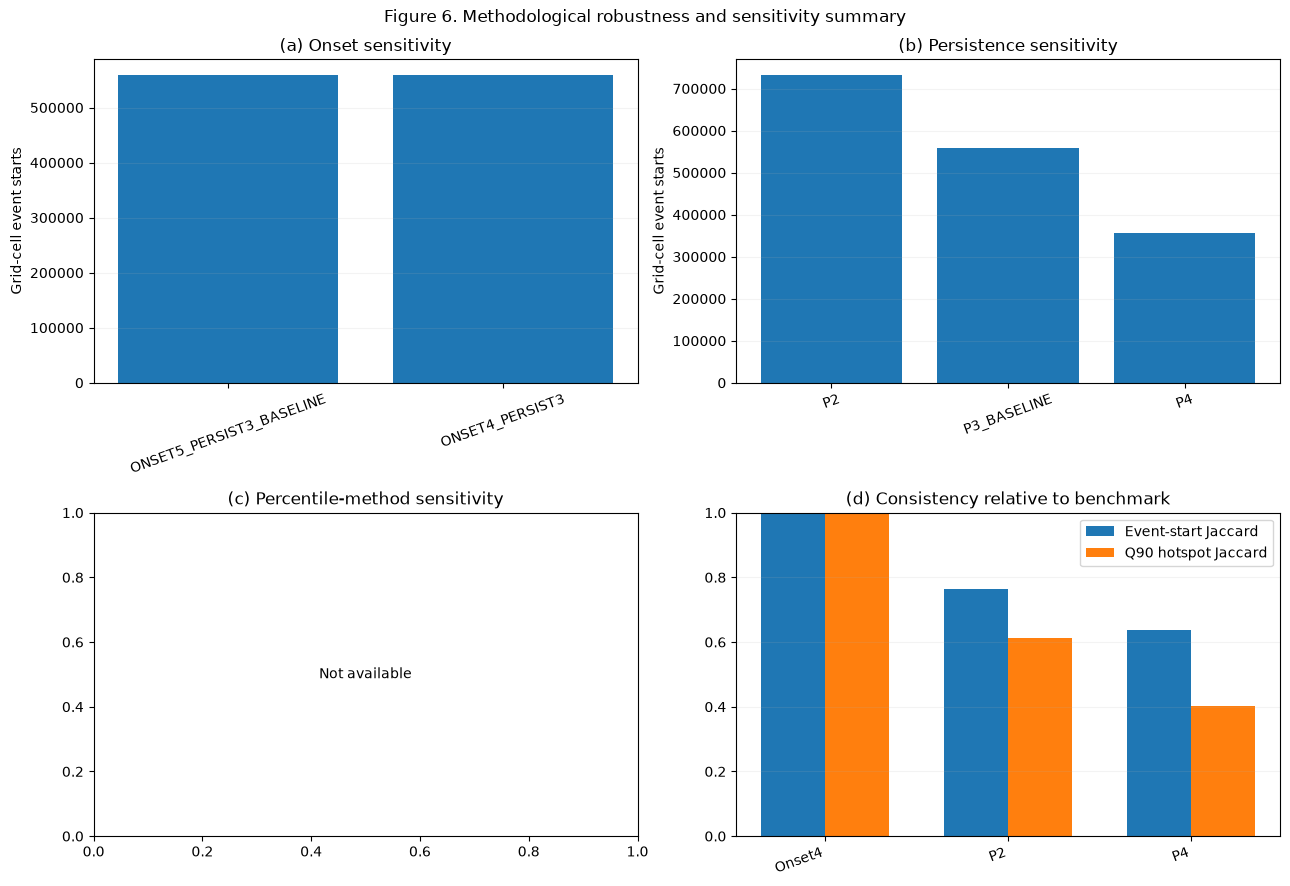

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

if onset_summary is not None:
    axes[0,0].bar(onset_summary["method"], onset_summary["gridcell_event_starts_1996_2024"])
    axes[0,0].set_title("(a) Onset sensitivity")
    axes[0,0].set_ylabel("Grid-cell event starts")
    axes[0,0].tick_params(axis="x", rotation=20)
    axes[0,0].grid(axis="y", alpha=0.15)
else:
    axes[0,0].text(0.5, 0.5, "Not available", ha="center", va="center")
    axes[0,0].set_title("(a) Onset sensitivity")

if persist_summary is not None:
    axes[0,1].bar(persist_summary["method"], persist_summary["gridcell_event_starts_1996_2024"])
    axes[0,1].set_title("(b) Persistence sensitivity")
    axes[0,1].set_ylabel("Grid-cell event starts")
    axes[0,1].tick_params(axis="x", rotation=20)
    axes[0,1].grid(axis="y", alpha=0.15)
else:
    axes[0,1].text(0.5, 0.5, "Not available", ha="center", va="center")
    axes[0,1].set_title("(b) Persistence sensitivity")

if pct_summary is not None:
    axes[1,0].bar(pct_summary["method"], pct_summary["gridcell_event_starts_1996_2024"])
    axes[1,0].set_title("(c) Percentile-method sensitivity")
    axes[1,0].set_ylabel("Grid-cell event starts")
    axes[1,0].tick_params(axis="x", rotation=20)
    axes[1,0].grid(axis="y", alpha=0.15)
else:
    axes[1,0].text(0.5, 0.5, "Not available", ha="center", va="center")
    axes[1,0].set_title("(c) Percentile-method sensitivity")

consistency_rows = []
if onset_consist is not None:
    rr = onset_consist.iloc[0]
    consistency_rows.append(("Onset4", rr["event_start_jaccard"], rr["q90_hotspot_jaccard"]))
if persist_consist is not None:
    for _, rr in persist_consist.iterrows():
        consistency_rows.append((rr["variant"], rr["event_start_jaccard"], rr["q90_hotspot_jaccard"]))
if pct_consist is not None:
    for _, rr in pct_consist.iterrows():
        consistency_rows.append((rr["variant"], rr["event_start_jaccard"], rr["q90_hotspot_jaccard"]))

if len(consistency_rows) > 0:
    cdf = pd.DataFrame(consistency_rows, columns=["variant", "event_start_jaccard", "hotspot_q90_jaccard"])
    x = np.arange(len(cdf))
    width = 0.35
    axes[1,1].bar(x - width/2, cdf["event_start_jaccard"], width=width, label="Event-start Jaccard")
    axes[1,1].bar(x + width/2, cdf["hotspot_q90_jaccard"], width=width, label="Q90 hotspot Jaccard")
    axes[1,1].set_xticks(x)
    axes[1,1].set_xticklabels(cdf["variant"], rotation=20, ha="right")
    axes[1,1].set_ylim(0, 1)
    axes[1,1].set_title("(d) Consistency relative to benchmark")
    axes[1,1].legend()
    axes[1,1].grid(axis="y", alpha=0.15)
else:
    axes[1,1].text(0.5, 0.5, "Not available", ha="center", va="center")
    axes[1,1].set_title("(d) Consistency relative to benchmark")

fig.suptitle("Figure 6. Methodological robustness and sensitivity summary")
fig.tight_layout()
fig.savefig(OUT / "Figure6_sensitivity_summary.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


# Supplementary Figure S1 — Hotspot masks


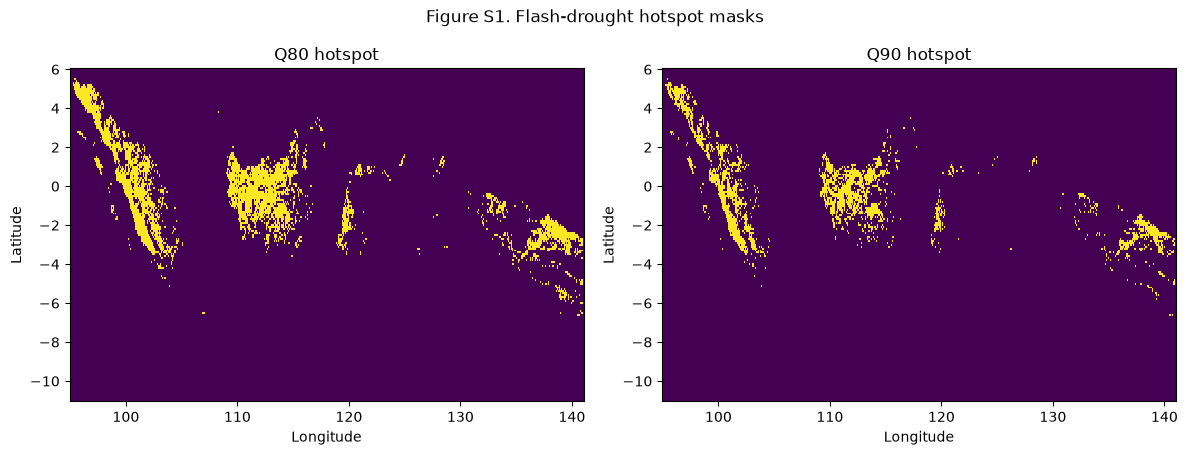

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, var, title in [
    (axes[0], "hotspot_q80", "Q80 hotspot"),
    (axes[1], "hotspot_q90", "Q90 hotspot"),
]:
    im = ax.pcolormesh(hot["longitude"], hot["latitude"], hot[var], shading="auto", vmin=0, vmax=1)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)

fig.suptitle("Figure S1. Flash-drought hotspot masks")
fig.tight_layout()
fig.savefig(OUT / "FigureS1_hotspot_masks.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


# Manuscript-ready text summary


In [12]:
p0 = metric_lag("tp_anom_mm", 0)
p1 = metric_lag("tp_anom_mm", 1)
t1 = metric_lag("t2m_anom_c", 1)
v1 = metric_lag("vpd_anom_kpa", 1)

zp = metric_phase("mean_z_precip")
zt = metric_phase("mean_z_t2m")
zv = metric_phase("mean_z_vpd")
fp = metric_phase("strong_precip_deficit_fraction")
fv = metric_phase("high_vpd_fraction")
fc = metric_phase("compound_pdef_highvpd_fraction")
fe = metric_phase("either_pdef_or_highvpd_fraction")

print("CORE RESULT SUMMARY")
print("-------------------")
print(
    f"At initiation (lag 0), precipitation anomaly = "
    f"{p0['mean']:.2f} mm pentad-1 "
    f"(95% CI {p0['ci95_low']:.2f} to {p0['ci95_high']:.2f})."
)
print(
    f"One pentad later, precipitation = {p1['mean']:.2f} mm pentad-1, "
    f"T2m = {t1['mean']:+.3f} °C, "
    f"VPD = {v1['mean']:+.3f} kPa."
)
print(
    f"During rapid development: mean standardized P = {zp[0]:+.3f}, "
    f"T2m = {zt[0]:+.3f}, VPD = {zv[0]:+.3f}."
)
print(
    f"Strong P-deficit fraction = {fp[0]*100:.1f}%; "
    f"high-VPD fraction = {fv[0]*100:.1f}%; "
    f"compound fraction = {fc[0]*100:.1f}%; "
    f"either-driver fraction = {fe[0]*100:.1f}%."
)


CORE RESULT SUMMARY
-------------------
At initiation (lag 0), precipitation anomaly = -2.75 mm pentad-1 (95% CI -4.21 to -1.23).
One pentad later, precipitation = -31.31 mm pentad-1, T2m = +0.424 °C, VPD = +0.149 kPa.
During rapid development: mean standardized P = -0.765, T2m = +0.449, VPD = +0.887.
Strong P-deficit fraction = 47.9%; high-VPD fraction = 46.8%; compound fraction = 37.0%; either-driver fraction = 57.7%.


In [13]:
manifest = {
    "purpose": "paper-style visual synthesis",
    "source_dirs": {
        "03d_climatology": str(CLIM_DIR),
        "04b_drivers": str(DRIVER_DIR),
        "03e_onset_sensitivity": str(ONSET_DIR),
        "03f_persistence_sensitivity": str(PERSIST_DIR),
        "03g_percentile_sensitivity": str(PCT_DIR),
    },
    "figures": {
        "Figure1": "Occurrence probability and frequency",
        "Figure2": "Onset speed, duration, persistence, severity",
        "Figure3": "Seasonality and interannual variability",
        "Figure4": "Event-aligned meteorological evolution",
        "Figure5": "Driver fingerprint",
        "Figure6": "Sensitivity and robustness summary",
        "FigureS1": "Hotspot masks",
    },
}
(OUT / "manifest_05_visual_results.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

clim.close()
hot.close()
print("Notebook 05 ready. Output directory:", OUT)


Notebook 05 ready. Output directory: D:\ERA5_LAND\output_fd_05_paper_visual_results
